<a href="https://colab.research.google.com/github/owen-simon/IS-6482-data-mining/blob/main/Week%207/A4_Simon_Owen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4 - Linear Regression

**Created:** 2026-03-23

**Author:** Owen Simon

---

## Task 1 - Load Packages, Read the Dataset

### Task 1A

In [97]:
# Load Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from google.colab import drive

RANDOM_STATE = 42

### Task 1B

In [98]:
# Read dataset and create DataFrame
drive.mount('/content/drive')
Video_Games = pd.read_csv('/content/drive/MyDrive/Data/NA_sales_filtered.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [99]:
# Analyze the head, info, shape of the DataFrame you created
Video_Games.head()

,Name,Platform,Genre,Rating,Critic_Score,Critic_Count,User_Score,User_Count,NA_Sales
0,Final Fantasy VII,PS,Role-Playing,T,92,20,91,1282,3.01
1,Final Fantasy X,PS2,Role-Playing,T,92,53,86,1056,2.91
2,The Sims 3,PC,Simulation,T,86,75,75,886,0.99
3,Final Fantasy VIII,PS,Role-Playing,T,90,24,85,644,2.28
4,Tekken 3,PS,Fighting,T,96,15,90,367,3.27


In [100]:
# Analyze the head, info, shape of the DataFrame you created
Video_Games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6345 entries, 0 to 6344
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          6345 non-null   object 
 1   Platform      6345 non-null   object 
 2   Genre         6345 non-null   object 
 3   Rating        6345 non-null   object 
 4   Critic_Score  6345 non-null   int64  
 5   Critic_Count  6345 non-null   int64  
 6   User_Score    6345 non-null   int64  
 7   User_Count    6345 non-null   int64  
 8   NA_Sales      6345 non-null   float64
dtypes: float64(1), int64(4), object(4)
memory usage: 446.3+ KB


In [101]:
# Analyze the head, info, shape of the DataFrame you created
Video_Games.shape

(6345, 9)

## Task 2 - Data Exploration

### Task 2A

In [102]:
# For each of the following columns, how many different values are there in the dataset? Which value is the most common? -- Platform, Genre, Rating
cols = ["Platform", "Genre", "Rating"]

for col in cols:
    print(f"{col}")
    print("Number of different values:", Video_Games[col].nunique())
    print("Most common value:", Video_Games[col].value_counts().idxmax())
    print()

Platform
Number of different values: 16
Most common value: PS2

Genre
Number of different values: 12
Most common value: Action

Rating
Number of different values: 5
Most common value: T



### Task 2B

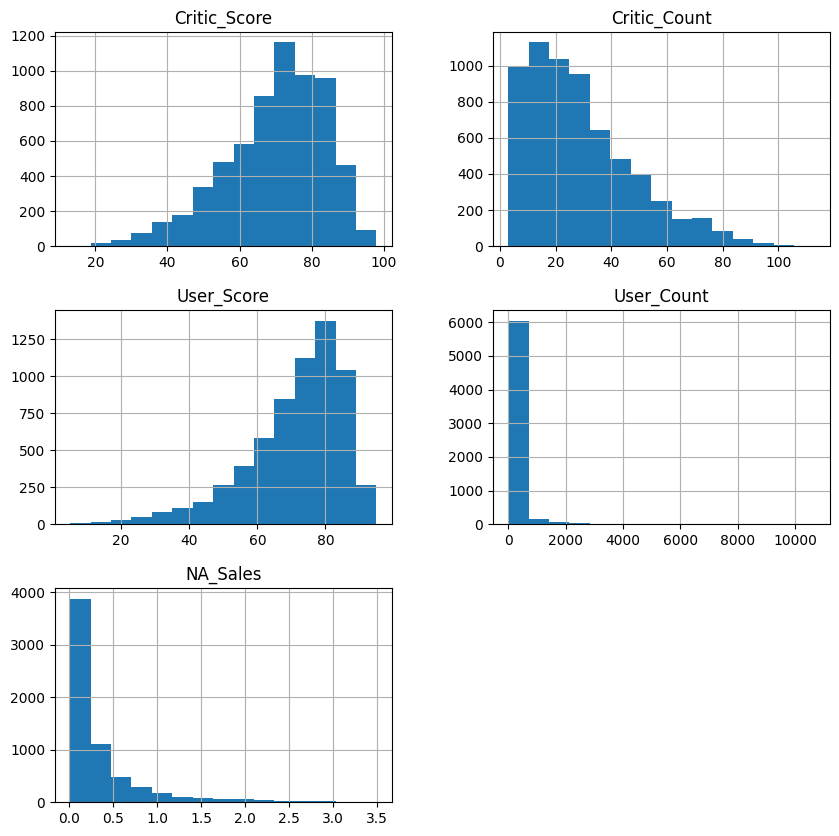

In [103]:
# Use the hist() function from pandas.DataFrame to plot the histogram of the numeric columns with 15 bins
Video_Games.hist(bins=15, figsize=(10, 10))
plt.show()

### Task 2C

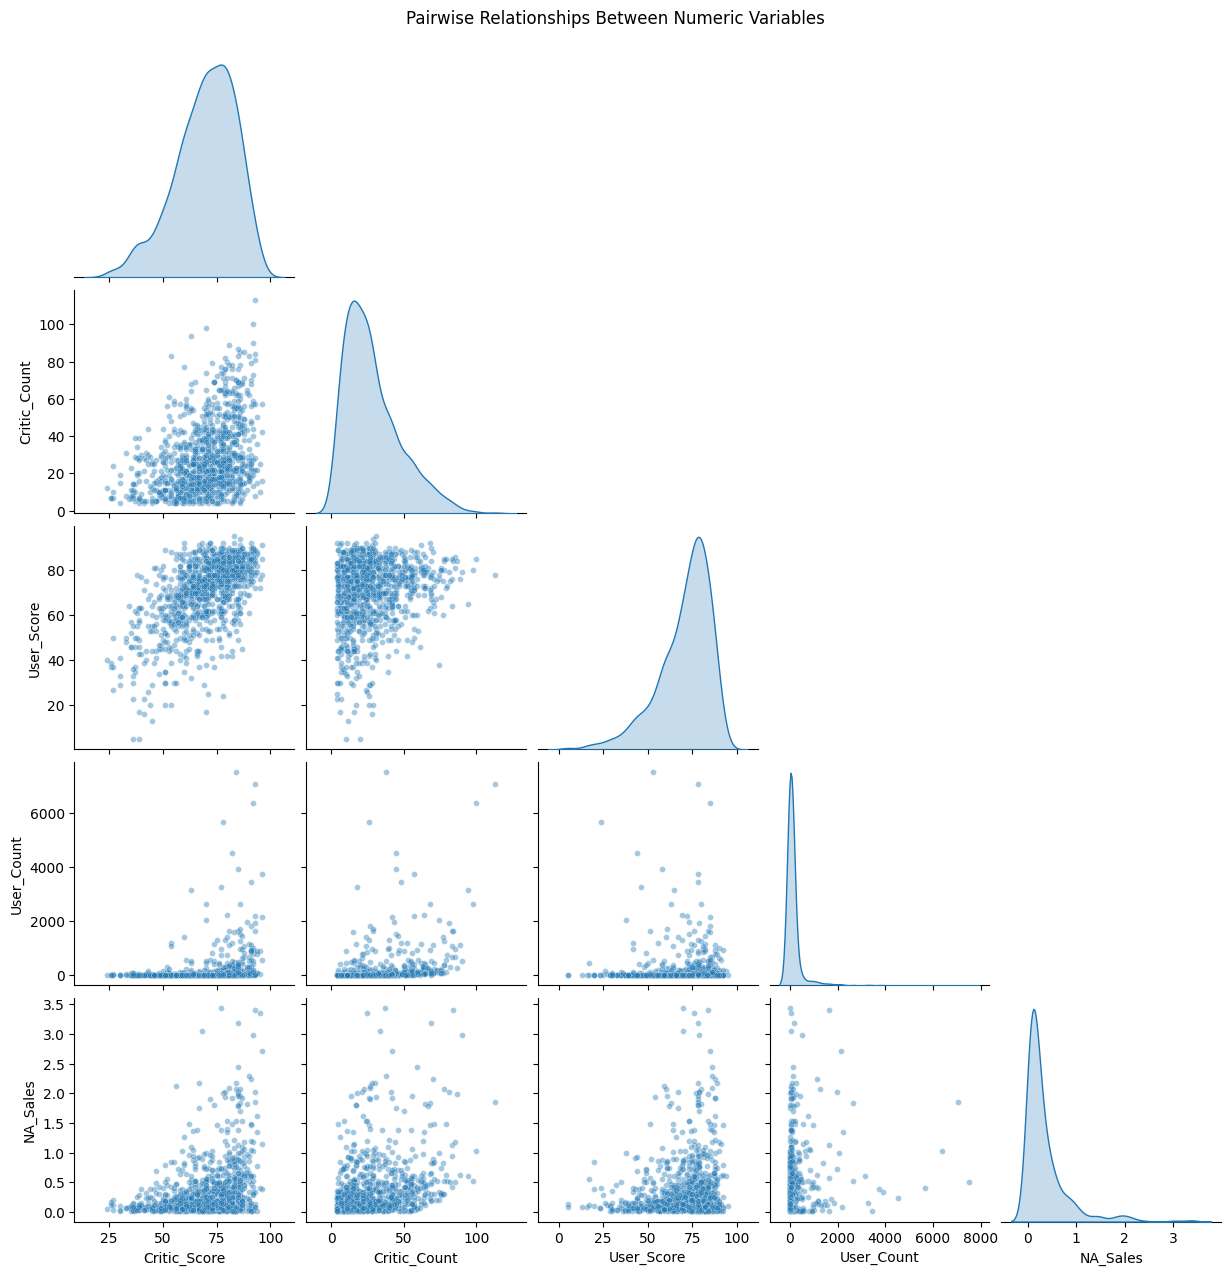

In [104]:
# For the pairplot function only: sample a smaller dataframe with 1000 rows.
sampled_df = Video_Games.sample(1000, random_state=RANDOM_STATE)

# Select only numeric columns
sampled_df_numeric = sampled_df.select_dtypes(include="number").columns

# Pairplot
g = sns.pairplot(
    data=sampled_df,
    vars=sampled_df_numeric,
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.4, "s": 18}
)

g.fig.suptitle("Pairwise Relationships Between Numeric Variables", y=1.02)
plt.show()

### Task 2D

In [105]:
# Use the corr() function from pandas.DataFrame to generate a correlation matrix for pairs of numeric feature.
corr = Video_Games.corr(numeric_only=True)
corr

,Critic_Score,Critic_Count,User_Score,User_Count,NA_Sales
Critic_Score,1.000000,0.390399,0.584548,0.243688,0.352974
Critic_Count,0.390399,1.000000,0.192762,0.348060,0.343505
User_Score,0.584548,0.192762,1.000000,0.012398,0.145351
User_Count,0.243688,0.348060,0.012398,1.000000,0.268393
NA_Sales,0.352974,0.343505,0.145351,0.268393,1.000000


<Axes: >

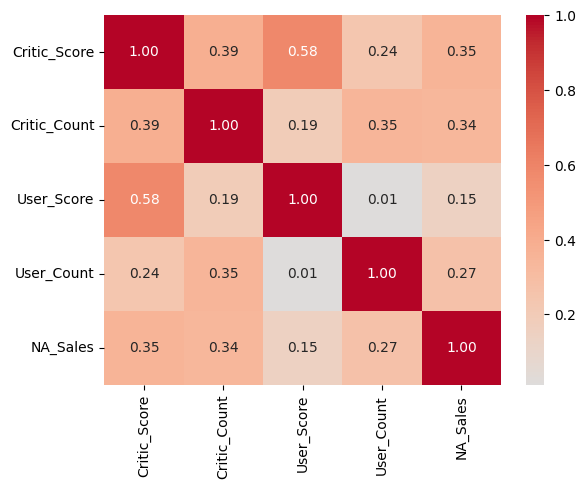

In [106]:
# Use the heatmap() function from seaborn to produce a heatmap of the correlation matrix
sns.heatmap(corr, center=0, annot=True, fmt = '.2f', cmap = 'coolwarm')

## Task 3 - Data Preparation

### Task 3A

In [107]:
# Drop the column 'Name' from the dataframe
Video_Games = Video_Games.drop(columns=["Name"])

# Separate out the column 'NA_sales' into a variable y and the rest of the dataframe into X
y = Video_Games['NA_Sales']
X = Video_Games.drop(columns=['NA_Sales'])

# Verify 'Name' column was dropped and 'NA_sales' is not included in X
X.head()

,Platform,Genre,Rating,Critic_Score,Critic_Count,User_Score,User_Count
0,PS,Role-Playing,T,92,20,91,1282
1,PS2,Role-Playing,T,92,53,86,1056
2,PC,Simulation,T,86,75,75,886
3,PS,Role-Playing,T,90,24,85,644
4,PS,Fighting,T,96,15,90,367


### Task 3B

In [108]:
# Use the pandas.get_dummies function to covert the categorical columns to one-hot-encoding.
cat_cols = X.select_dtypes(include="object").columns

X = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

# Verify one-hot-encoding was applied
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6345 entries, 0 to 6344
Data columns (total 34 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Critic_Score        6345 non-null   int64
 1   Critic_Count        6345 non-null   int64
 2   User_Score          6345 non-null   int64
 3   User_Count          6345 non-null   int64
 4   Platform_DS         6345 non-null   int64
 5   Platform_GBA        6345 non-null   int64
 6   Platform_GC         6345 non-null   int64
 7   Platform_PC         6345 non-null   int64
 8   Platform_PS         6345 non-null   int64
 9   Platform_PS2        6345 non-null   int64
 10  Platform_PS3        6345 non-null   int64
 11  Platform_PS4        6345 non-null   int64
 12  Platform_PSP        6345 non-null   int64
 13  Platform_PSV        6345 non-null   int64
 14  Platform_Wii        6345 non-null   int64
 15  Platform_WiiU       6345 non-null   int64
 16  Platform_X360       6345 non-null   int64


### Task 3C

In [109]:
# Get the dataframe ready for linear regression by adding a column of all 1's using the add_constant() function
X = sm.add_constant(X)

# Verify addition of 'const' column
X.head()

,const,Critic_Score,Critic_Count,User_Score,User_Count,Platform_DS,Platform_GBA,Platform_GC,Platform_PC,Platform_PS,...,Genre_Racing,Genre_Role-Playing,Genre_Shooter,Genre_Simulation,Genre_Sports,Genre_Strategy,Rating_E10+,Rating_M,Rating_T,Rating_missing
0,1.0,92,20,91,1282,0,0,0,0,1,...,0,1,0,0,0,0,0,0,1,0
1,1.0,92,53,86,1056,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
2,1.0,86,75,75,886,0,0,0,1,0,...,0,0,0,1,0,0,0,0,1,0
3,1.0,90,24,85,644,0,0,0,0,1,...,0,1,0,0,0,0,0,0,1,0
4,1.0,96,15,90,367,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0


## Task 4 - First Linear Regression Model and Performance Metrics

### Task 4A

In [110]:
# Perform a 70/30 train/test split on the dataframe you get after the previous step
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE)

# Train a linear regression model using OLS()
ols_model = sm.OLS(y_train, X_train).fit()

### Task 4B

In [111]:
# Print the summary of the fitted model
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:               NA_Sales   R-squared:                       0.284
Model:                            OLS   Adj. R-squared:                  0.278
Method:                 Least Squares   F-statistic:                     51.34
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          1.40e-288
Time:                        01:34:58   Log-Likelihood:                -2478.8
No. Observations:                4441   AIC:                             5028.
Df Residuals:                    4406   BIC:                             5252.
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.3582      0

In [112]:
# What is the R-squared on the train set?
r_squared = ols_model.rsquared
print("R-squared:", round(r_squared, 3))

R-squared: 0.284


In [113]:
# Which three features are the most important based on the t-statistic in your report?
t_stats = (ols_model.tvalues
           .drop("const"))

top_features = (t_stats.abs()
                .sort_values(ascending=False)
                .head(3))

print("Three Most Important Features:")
for feature, t_value in top_features.items():
    print(f"{feature}: {t_value:.4f}")

Three Most Important Features:
User_Count: 15.9277
Critic_Score: 15.7657
Critic_Count: 13.9025


### Task 4C



**Interpretation of the `Genre_Puzzle` coefficient:**  

The coefficient of -0.1528 indicates that, holding all other factors constant, games classified as Puzzle are associated with an average **decrease of 0.1528 units in North American sales** compared to games classified as the reference genre (*Action*).

### Task 4D

In [114]:
# Find the mean squared error of your fitted linear regression model on the train split and on the test split.
y_train_pred = ols_model.predict(X_train)
y_test_pred = ols_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print("Train Split Mean Squared Error:", round(train_mse, 4))
print("Test Split Mean Squared Error:", round(test_mse, 4))

Train Split Mean Squared Error: 0.1788
Test Split Mean Squared Error: 0.1725


## Task 5 - Second Linear Regression Model

### Task 5A

In [115]:
# Create and add the quadratic term of 'Critic_Score' to the predictors
X_train["Critic_Score_Squared"] = X_train["Critic_Score"] ** 2
X_test["Critic_Score_Squared"] = X_test["Critic_Score"] ** 2

### Task 5B

In [116]:
# Train another linear regression model on the train split
second_ols_model = sm.OLS(y_train, X_train).fit()

# Print the summary of the fitted model
print(second_ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:               NA_Sales   R-squared:                       0.314
Model:                            OLS   Adj. R-squared:                  0.309
Method:                 Least Squares   F-statistic:                     57.60
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        01:34:58   Log-Likelihood:                -2383.1
No. Observations:                4441   AIC:                             4838.
Df Residuals:                    4405   BIC:                             5069.
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.9733 

In [117]:
# What is the R-squared on the train set?
r_squared = second_ols_model.rsquared
print("R-squared:", round(r_squared, 3))

R-squared: 0.314


In [118]:
# Which three features are the most important based on the t-statistic in your report?
t_stats = (second_ols_model.tvalues
           .drop("const"))

top_features = (t_stats.abs()
                .sort_values(ascending=False)
                .head(3))

print("Three Most Important Features:")
for feature, t_value in top_features.items():
    print(f"{feature}: {t_value:.4f}")

Three Most Important Features:
Critic_Score_Squared: 13.9325
User_Count: 13.0849
Critic_Count: 12.8584


### Task 5C

In [119]:
# Find the mean squared error of your fitted linear regression model on the train split and on the test split.
y_train_pred = second_ols_model.predict(X_train)
y_test_pred = second_ols_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print("Train Split Mean Squared Error:", round(train_mse, 4))
print("Test Split Mean Squared Error:", round(test_mse, 4))

Train Split Mean Squared Error: 0.1712
Test Split Mean Squared Error: 0.1686


## Task 6 - Third Linear Regression Model

### Task 6A

In [120]:
# Create and add the natural log transformation of 'User_Count' to the predictors
X_train["log_User_Count"] = np.log(X_train["User_Count"])
X_test["log_User_Count"] = np.log(X_test["User_Count"])

# Drop the original 'User_Count' column from the predictors
X_train = X_train.drop(columns=["User_Count"])
X_test = X_test.drop(columns=["User_Count"])

# Also drop the quadratic term in Critic_Score
X_train = X_train.drop(columns=["Critic_Score_Squared"])
X_test = X_test.drop(columns=["Critic_Score_Squared"])

### Task 6B

In [121]:
# Train another linear regression model on the train split
third_ols_model = sm.OLS(y_train, X_train).fit()

# Print the summary of the fitted model
print(third_ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:               NA_Sales   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.364
Method:                 Least Squares   F-statistic:                     75.73
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        01:34:58   Log-Likelihood:                -2198.0
No. Observations:                4441   AIC:                             4466.
Df Residuals:                    4406   BIC:                             4690.
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.7036      0

In [122]:
# What is the R-squared on the train set?
r_squared = third_ols_model.rsquared
print("R-squared:", round(r_squared, 3))

R-squared: 0.369


In [123]:
# Which three features are the most important based on the t-statistic in your report?
t_stats = (third_ols_model.tvalues
           .drop("const"))

top_features = (t_stats.abs()
                .sort_values(ascending=False)
                .head(3))

print("Three Most Important Features:")
for feature, t_value in top_features.items():
    print(f"{feature}: {t_value:.4f}")

Three Most Important Features:
log_User_Count: 29.6954
Critic_Score: 9.0499
Rating_M: 8.9357


### Task 6C

In [124]:
# Find the mean squared error of your fitted linear regression model on the train split and on the test split.
y_train_pred = third_ols_model.predict(X_train)
y_test_pred = third_ols_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print("Train Split Mean Squared Error:", round(train_mse, 4))
print("Test Split Mean Squared Error:", round(test_mse, 4))

Train Split Mean Squared Error: 0.1576
Test Split Mean Squared Error: 0.1529


## Task 7 - Interpret Your Models and Write Your Reflection


### Task 7A
Across the three linear regression models, several predictors consistently show limited evidence of a statistically significant association with `NA_Sales`, as indicated by high p-values. These variables include `Genre_Fighting`, `Genre_Racing`, `Genre_Shooter`, and `Platform_WiiU`. Removing these variables would produce a more parsimonious model while maintaining predictive quality.


### Task 7B

The natural log transformation of `User_Count` improves model performance because the raw variable is highly right skewed and spans a wide range **[0, 10,665]**, while its correlation with `NA_Sales` is only moderate **(0.268)**. Logging `User_Count` stabilizes variance and compresses extreme values, increasing R-squared from **0.314** to **0.369** and reducing RMSE, indicating improved model fit.**bold text**


### Task 7C

Adding a quadratic term for `Critic_Score` captures nonlinear effects; however, a quadratic term for `User_Count` is not necessary because the log transformation already addresses the strong right skew and helps linearize its relationship with `NA_Sales`.

### Task 7D

Interaction terms between rating and genre variables, or between critic score and user count, could further improve performance by allowing the effect of ratings to vary across genres and the effect of critic scores to depend on the level of user engagement. Other transformations, such as a log transformation of `NA_Sales`, may also improve performance since sales are also heavily right skewed. If `NA_Sales` were log transformed, model performance would need to be compared using metrics evaluated on the same scale, such as out-of-sample prediction error computed on the original sales scale. Model comparisons would rely on R-squared, adjusted R-squared, and RMSE where appropriate.